In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score, precision_recall_curve, auc, roc_auc_score,average_precision_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.ensemble import IsolationForest
from lightgbm import LGBMClassifier
from scipy.stats import uniform, loguniform, randint

# 1. Load Data

In [2]:
df_raw = pd.read_csv('clean_data.csv')
df = df_raw.copy()

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,hour_of_day,day_of_week,accountDrained,isHighAmount
0,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0.00,181.0,1,0,1,0
1,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0.00,21363.0,1,0,1,0
2,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,-213808.94,182703.5,1,0,1,0
3,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,-214605.30,237735.3,1,0,1,0
4,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,-300850.89,-2401220.0,1,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2770409 entries, 0 to 2770408
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   step              int64  
 1   type              object 
 2   amount            float64
 3   nameOrig          object 
 4   oldbalanceOrg     float64
 5   newbalanceOrig    float64
 6   nameDest          object 
 7   oldbalanceDest    float64
 8   newbalanceDest    float64
 9   isFraud           int64  
 10  errorBalanceOrig  float64
 11  errorBalanceDest  float64
 12  hour_of_day       int64  
 13  day_of_week       int64  
 14  accountDrained    int64  
 15  isHighAmount      int64  
dtypes: float64(7), int64(6), object(3)
memory usage: 338.2+ MB


# 2. Data Preprocessing

In [5]:
df = pd.get_dummies(df,columns=['type'], drop_first=True, dtype=int)

In [6]:
df = df.drop(columns=['step','nameOrig'])

# 3. Split Data

In [7]:
X = df.drop(columns='isFraud')
y = df['isFraud']
X_train, X_test, y_train, y_test  = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train = X_train.copy()
X_test = X_test.copy()

dest_counts = X_train['nameDest'].value_counts()
X_train['destTransactionCount'] = X_train['nameDest'].map(dest_counts)
X_test['destTransactionCount'] = X_test['nameDest'].map(dest_counts).fillna(1)

X_train = X_train.drop(columns=['nameDest'])
X_test = X_test.drop(columns=['nameDest'])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 3.1  Hyperparameter Tuning Subset (10%)

Due to the large data volume (over 2.2 million records in the training set), hyperparameter tuning (which requires hundreds of model fits) is performed on a stratified 10% sample of the training data (X_tune). This approach significantly optimizes compute resources and reduces training time, while maintaining the exact class distribution of the extreme minority Fraud class. The best parameters found on this subset will be applied to the final model.

In [8]:
X_tune, _, y_tune,_ = train_test_split(X_train, y_train, train_size=0.1, stratify=y_train, random_state=42)

# 4. Result Function

In [30]:
def results(model_name, y_test, y_pred, y_scores=None):
    print(f"  {model_name}")
    print("--------------")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1:        {f1_score(y_test, y_pred):.4f}")
    if y_scores is not None:
        print(f"PR-AUC:    {average_precision_score(y_test, y_scores):.4f}")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
def feature_importance(model, feature_names, title, top_n=15):
    estimator = model
    importances = estimator.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    fi.plot(kind='barh', color='teal')
    plt.title(f'Feature Importances - {title}', fontsize=14)
    plt.xlabel('Absolute coefficient value', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
def coefficients(model, feature_names, top_n=15):
    coefs = model.named_steps['log_reg'].coef_[0]
    fi = pd.Series(coefs, index=feature_names)
    fi = fi.abs().sort_values(ascending=True).tail(int(top_n))
    plt.figure(figsize=(8,6))
    fi.plot(kind='barh')
    plt.title('Feature Importance - Logistic Regression Tuned')
    plt.xlabel('Absolute coefficient value')
    plt.tight_layout()
    plt.show()

# 5. Logisitic Regression (Baseline Model)

## 5.1 First Model (Default Settings)

This baseline model is trained on the full training dataset (100% of X_train) using default parameters to establish a true performance baseline "out-of-the-box".

In [10]:
model_log = make_pipeline(StandardScaler(), LogisticRegression())
model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_test)
y_score_log = model_log.predict_proba(X_test)[:, -1]

## 5.2 Model Results

  Logistic Regression - Default
--------------
Precision: 0.9188
Recall:    0.5782
F1:        0.7097
PR-AUC:    0.7779


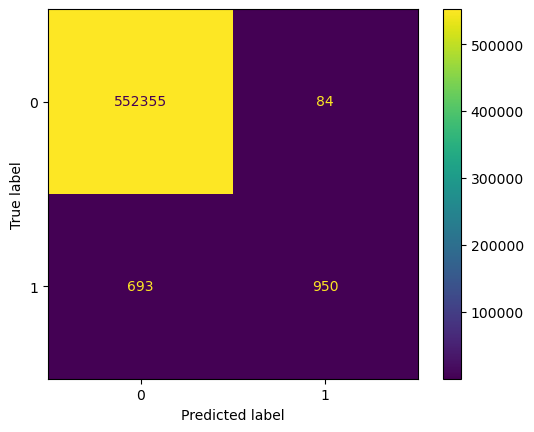

In [31]:
results("Logistic Regression - Default", y_test, y_pred_log, y_score_log)

**Insights:**  
1. **Business Impact (Confusion Matrix for Fraud):**
* **Caught Frauds (True Positive):** The model successfully intercepted **950** fraudulent transactions, directly preventing financial loss for the bank and the customer.
* **Missed Frauds (False Negative):** The model failed to detect **693** frauds. This is the most critical metric, as it represents stolen funds that the bank might need to refund.
* **False Alarms (False Positive):** The model incorrectly flagged **84** legitimate transactions as fraud. This represents operational costs (alerts for the Customer Service team) and unnecessary friction for loyal customers whose transfers were blocked.
2. **Key Fraud Detection Metrics:**
  * **Recall:** Out of all actual fraudulent transactions, the model successfully detected **57.82 %**. In banking, maximizing this metric is a priority to minimize direct financial losses.
  * **Precision:** When the model rings the alarm and blocks a transfer, it is correct **91.88 %** of the time.
  * **F1 Score:** The overall effectiveness of this model at handling the minority Fraud class is **70.97 %**.
  * **PR-AUC:** The overall effectiveness of this model at balancing the extreme minority class (frauds are only 0.13%) is **77.79 %**.

## 5.3 Logistic Regression - Tuned

In [12]:
pipe_log_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(random_state=7))
])
param_log_tuned = {
    'log_reg__C': loguniform(0.001, 100),
    'log_reg__penalty': ['l1','l2','elasticnet'],
    'log_reg__solver': ['saga'],
    'log_reg__l1_ratio': uniform(0,1),
    'log_reg__max_iter': [2000,5000],
    'log_reg__class_weight': ['balanced', None]
}
search_log_tuned = RandomizedSearchCV(estimator=pipe_log_tuned,
                           param_distributions = param_log_tuned,
                           n_iter = 20,
                           cv=skf,
                           scoring='average_precision',
                           n_jobs=-1,
                           random_state=42,
                           verbose=1)
search_log_tuned.fit(X_tune, y_tune)
print('The best parameters:', search_log_tuned.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\Oliwer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


The best parameters: {'log_reg__C': np.float64(42.982762978218666), 'log_reg__class_weight': 'balanced', 'log_reg__l1_ratio': np.float64(0.9218742350231168), 'log_reg__max_iter': 5000, 'log_reg__penalty': 'l2', 'log_reg__solver': 'saga'}


In [13]:
best_model_log_tuned = search_log_tuned.best_estimator_
y_pred_log_tuned = best_model_log_tuned.predict(X_test)
y_scores_log_tuned = search_log_tuned.best_estimator_.predict_proba(X_test)[:, 1]

## 5.5 Model Results

  Logistic Regression - Tuned
--------------
Precision: 0.1001
Recall:    0.9726
F1:        0.1814
PR-AUC:    0.7844


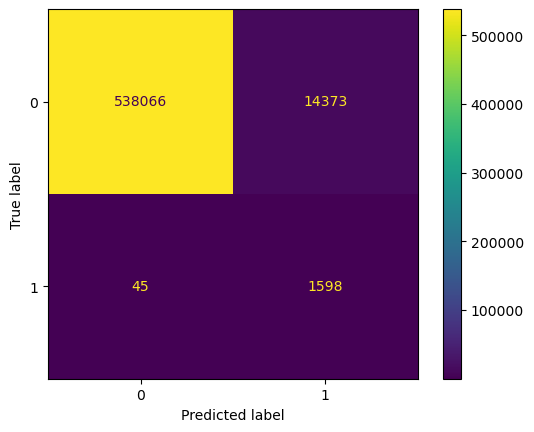

In [32]:
results("Logistic Regression - Tuned", y_test, y_pred_log_tuned, y_scores_log_tuned)


**Insights:**  
1. **Business Impact (Confusion Matrix for Fraud):**
* **Caught Frauds (True Positive):** The model successfully intercepted **1598** fraudulent transactions, directly preventing financial loss for the bank and the customer. Hyperparameter tuning enabled the model to detect an additional **648** frauds compared to the default configuration.
* **Missed Frauds (False Negative):** The model failed to detect **45** frauds. This is the most critical metric, as it represents stolen funds that the bank might need to refund. Consequently, the number of undetected, critical frauds dropped significantly (by **648** cases compared to the baseline). From a risk management perspective, this drastically reduces the bank's financial liability.
* **False Alarms (False Positive):** However, this increased sensitivity comes at a heavy operational cost. The tuned model incorrectly flagged **14373** legitimate transactions as fraud (compared to just **84** in the default model). This represents a classic Recall vs. Precision trade-off. While the model catches almost all frauds, the Customer Service team would need to handle a significantly higher volume of blocked legitimate transfers.
2. **Key Fraud Detection Metrics:**
  * **Recall:** Out of all actual fraudulent transactions, the model successfully detected **97.26 %**. In banking, maximizing this metric is a priority to minimize direct financial losses.
  * **Precision:** When the model rings the alarm and blocks a transfer, it is correct **10.01 %** of the time.
  * **F1 Score:** The overall effectiveness of this model at handling the minority Fraud class is **18.14 %**.
  * **PR-AUC:** The overall effectiveness of this model at balancing the extreme minority class (frauds are only 0.13%) is **78.44 %**.

  
**Conclusion:**

While hyperparameter tuning successfully maximized our Recall (catching over **97 %** of frauds), the extreme drop in Precision makes this Logistic Regression model operationally unviable for a bank. Generating over **14000** false alarms on just a **10 %** data sample would paralyze the Customer Service department and severely damage the Customer Experience. This clearly demonstrates that simple linear models struggle to find an intelligent boundary in cases of extreme class imbalance (0.13%).

# 5.6 Feature Importance

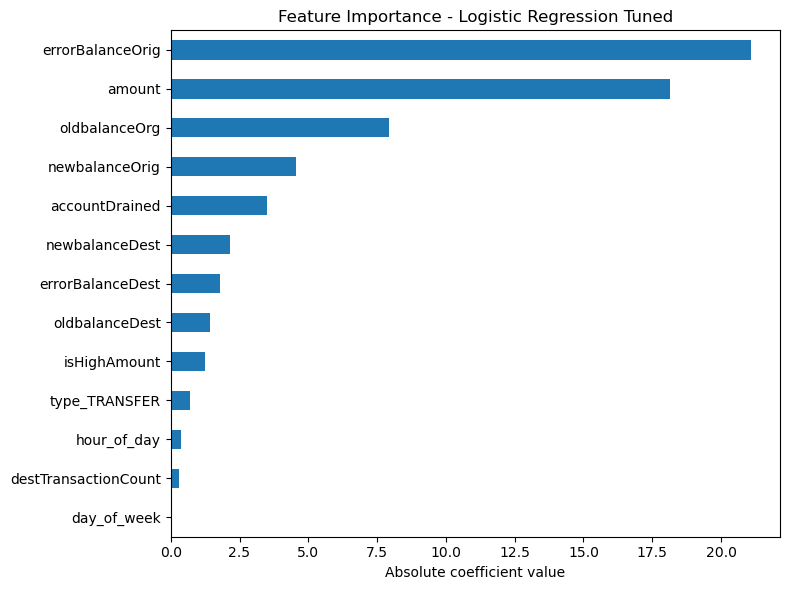

In [15]:
coefficients(best_model_log_tuned ,X_tune.columns)

# 6. LGBMClassifier

## 6.1 First Model (Default Settings)

In [16]:
model_lgbc = LGBMClassifier()
model_lgbc.fit(X_train,y_train)
y_pred_lgbc = model_lgbc.predict(X_test)
y_score_lgbc = model_lgbc.predict_proba(X_test)[:, -1]

[LightGBM] [Info] Number of positive: 6570, number of negative: 2209757
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1877
[LightGBM] [Info] Number of data points in the train set: 2216327, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002964 -> initscore=-5.818124
[LightGBM] [Info] Start training from score -5.818124


## 6.2 Model Results

  LGBMClassifier - Default
--------------
Precision: 0.6032
Recall:    0.5819
F1:        0.5923
PR-AUC:    0.3623


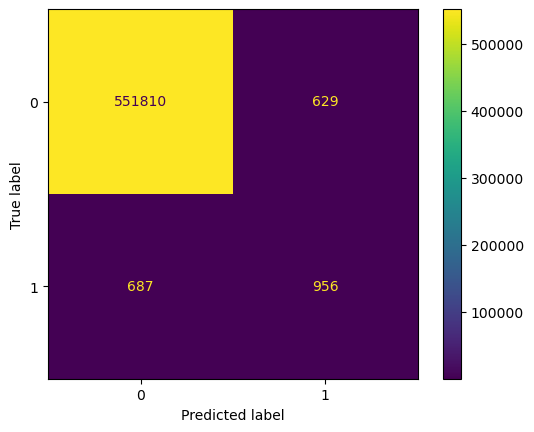

In [33]:
results("LGBMClassifier - Default", y_test, y_pred_lgbc, y_score_lgbc)

**Insights:**  
1. **Business Impact (Confusion Matrix for Fraud):**
* **Caught Frauds (True Positive):** The model successfully intercepted **956** fraudulent transactions, directly preventing financial loss for the bank and the customer.
* **Missed Frauds (False Negative):** The model failed to detect **687** frauds. This is the most critical metric, as it represents stolen funds that the bank might need to refund.
* **False Alarms (False Positive):** The model incorrectly flagged **629** legitimate transactions as fraud. This represents operational costs (alerts for the Customer Service team) and unnecessary friction for loyal customers whose transfers were blocked.
2. **Key Fraud Detection Metrics:**
  * **Recall:** Out of all actual fraudulent transactions, the model successfully detected **58.19 %**. In banking, maximizing this metric is a priority to minimize direct financial losses.
  * **Precision:** When the model rings the alarm and blocks a transfer, it is correct **60.32 %** of the time.
  * **F1 Score:** The overall effectiveness of this model at handling the minority Fraud class is **59.23 %**.
  * **PR-AUC:** The overall effectiveness of this model at balancing the extreme minority class (frauds are only 0.13%) is **36.23 %**.

## 6.3 LGBMClassifier - Tuned

In [18]:

param_lgbm_tuned = {
    'n_estimators':      [500, 1000, 2000],
    'max_depth':         [4, 6, 8, -1],
    'learning_rate':     loguniform(0.01, 0.3),
    'num_leaves':        [31, 63, 127],
    'min_child_samples': [20, 50, 100],
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'class_weight':      ['balanced', None]
}
search_lgbm_tuned = RandomizedSearchCV(
                        estimator=LGBMClassifier(
                         random_state=42,
                         n_jobs = -1,
                         verbose=-1),
    param_distributions=param_lgbm_tuned,
    n_iter=50,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search_lgbm_tuned.fit(X_tune, y_tune)
print('The best parameters:', search_lgbm_tuned.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
The best parameters: {'class_weight': None, 'colsample_bytree': np.float64(0.6643232205669994), 'learning_rate': np.float64(0.064646697464924), 'max_depth': 6, 'min_child_samples': 100, 'n_estimators': 500, 'num_leaves': 31, 'subsample': np.float64(0.6703701010709381)}


In [19]:
best_model_lgbm_tuned = search_lgbm_tuned.best_estimator_
y_pred_lgbm_tuned = best_model_lgbm_tuned.predict(X_test)
y_scores_lgbm_tuned = search_lgbm_tuned.best_estimator_.predict_proba(X_test)[:, 1]

## 6.4 Model Results

  LGBMClassifier - Tuned
--------------
Precision: 0.9988
Recall:    0.9927
F1:        0.9957
PR-AUC:    0.9965


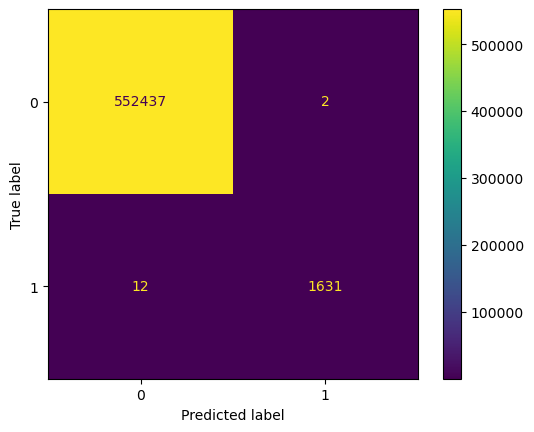

In [34]:
results("LGBMClassifier - Tuned", y_test, y_pred_lgbm_tuned, y_scores_lgbm_tuned)

**Insighst:**  
1. **Business Impact (Confusion Matrix for Fraud):**
   * **Caught Frauds (True Positive):** The tuned LightGBM model successfully intercepted **1631** fraudulent transactions. Hyperparameter tuning enabled the model to detect an additional **675** frauds compared to its default configuration, maximizing the protection of customer funds.
   * **Missed Frauds (False Negative):** The model failed to detect only **12** frauds out of **1643**. This near-perfect detection rate drastically minimizes the bank's financial liability.
   * **False Alarms (False Positive):** In an extraordinary achievement, the tuned model incorrectly flagged only **2** legitimate transactions out of over **554000**. This means the Customer Service team will experience zero operational burden, and honest customers will face no friction.
2. **Key Fraud Detection Metrics:**
   * **Recall:** The model successfully detected **99.27 %** of all frauds, achieving optimal security.
   * **Precision:** An astonishing **99.88 %**. When this model flags a transaction, it is almost flawlessly accurate.
   * **F1 Score & PR-AUC:** Both metrics are exceptional (**99.57 %** and **99.65 %** respectively), proving that LightGBM perfectly isolated the extreme minority Fraud class (0.13%) without falling into the Precision-Recall trade-off trap.

**Conclusion**  
Unlike the Logistic Regression, which generated over **14000** false alarms to catch frauds, the tuned LightGBM achieved near-perfect Recall while maintaining absolute Precision. Furthermore, the hyperparameter tuning process proved its immense value—it transformed a mediocre baseline LightGBM (which caught only **~ 58%** of frauds) into an industry-leading, robust solution.

# 6.5 Feature Importance

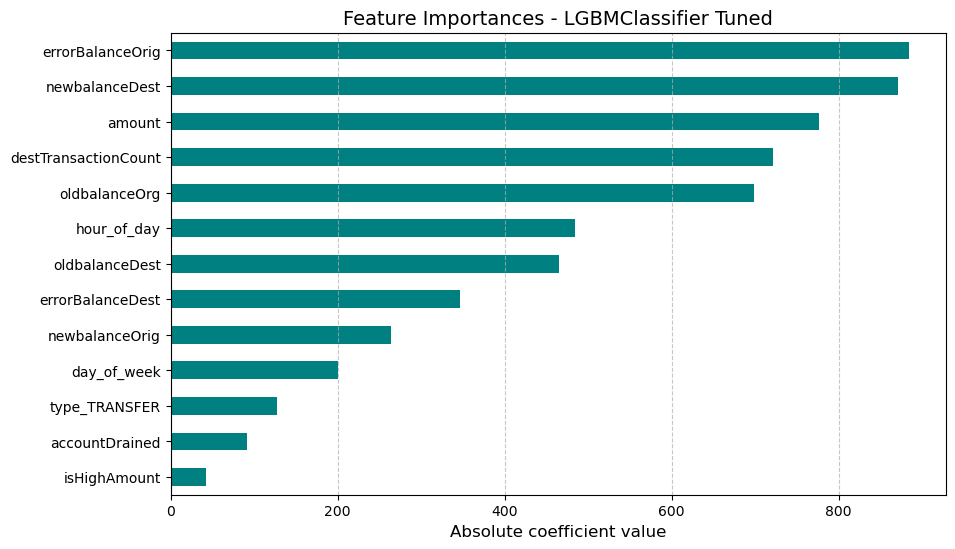

In [21]:
feature_importance(best_model_lgbm_tuned, X_tune.columns, "LGBMClassifier Tuned")

# 7. Isolation Forest

## 7.1 First Model (Default Settings)

In [22]:
model_if = IsolationForest()
model_if.fit(X_train,y_train)
y_pred_if = (model_if.predict(X_test) == -1).astype(int)
y_score_if = -model_if.score_samples(X_test)

## 7.2 Model Results

  Isolation Forest - Default
--------------
Precision: 0.0154
Recall:    0.6488
F1:        0.0301
PR-AUC:    0.0340


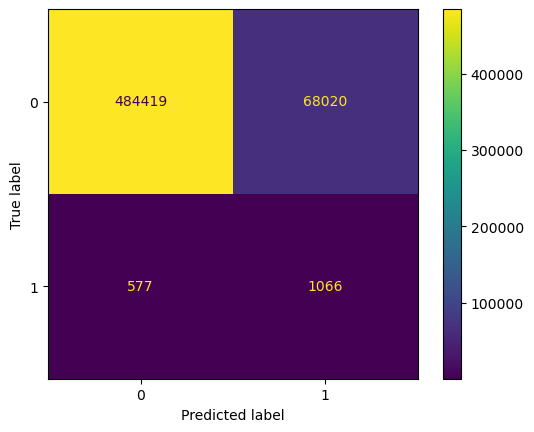

In [35]:
results("Isolation Forest - Default", y_test, y_pred_if, y_score_if)

**Insights:**  
1. **Business Impact (Confusion Matrix for Fraud):**
* **Caught Frauds (True Positive):** The model successfully intercepted **1066** fraudulent transactions, directly preventing financial loss for the bank and the customer.
* **Missed Frauds (False Negative):** The model failed to detect **577** frauds. This is the most critical metric, as it represents stolen funds that the bank might need to refund.
* **False Alarms (False Positive):** The model incorrectly flagged **68020** legitimate transactions as fraud. This represents operational costs (alerts for the Customer Service team) and unnecessary friction for loyal customers whose transfers were blocked.
2. **Key Fraud Detection Metrics:**
  * **Recall:** Out of all actual fraudulent transactions, the model successfully detected **64.88 %**. In banking, maximizing this metric is a priority to minimize direct financial losses.
  * **Precision:** When the model rings the alarm and blocks a transfer, it is correct **1.54 %** of the time.
  * **F1 Score:** The overall effectiveness of this model at handling the minority Fraud class is **3.01 %**.
  * **PR-AUC:** The overall effectiveness of this model at balancing the extreme minority class (frauds are only 0.13%) is **3.4 %**.

## 7.3 Isolation Forest - Tuned

In [24]:
param_if_tuned = {
    'n_estimators':  [100, 200, 500],
    'max_samples':   ['auto', 0.5, 0.8],
    'contamination': [0.001, 0.005, 0.01, 0.02],
    'max_features':  [0.5, 0.8, 1.0]
}

search_if_tuned = RandomizedSearchCV(
    estimator=IsolationForest(random_state=42),
    param_distributions=param_if_tuned,
    n_iter=30,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search_if_tuned.fit(X_tune, y_tune)
print('The best parameters:', search_if_tuned.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters: {'n_estimators': 200, 'max_samples': 'auto', 'max_features': 0.8, 'contamination': 0.001}


In [25]:
best_model_if_tuned = search_if_tuned.best_estimator_
y_pred_if_tuned = (best_model_if_tuned.predict(X_test) == -1).astype(int)
y_score_if_tuned = -best_model_if_tuned.score_samples(X_test)

## 7.4 Model Results

  Isolation Forest - Tuned
--------------
Precision: 0.0016
Recall:    0.0006
F1:        0.0009
PR-AUC:    0.0206


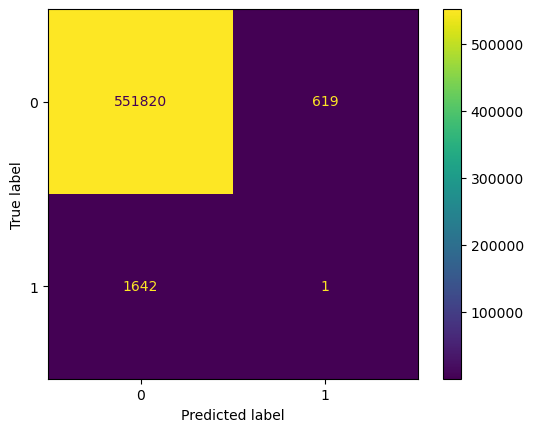

In [36]:
results("Isolation Forest - Tuned", y_test, y_pred_if_tuned, y_score_if_tuned)

**Insights:**  
1. **Business Impact (Confusion Matrix for Fraud):**
* **Caught Frauds (True Positive):** The tuned model successfully intercepted only **1** single fraudulent transaction. This is a catastrophic failure from a risk management perspective.
* **Missed Frauds (False Negative):** The model completely missed **1642** frauds, allowing almost 100% of the stolen funds to slip through the system.
* **False Alarms (False Positive):**  While hyperparameter tuning reduced the false alarms to **619** (down from a massive **~ 68,000** in the default model), it did so at the cost of completely destroying the model's ability to detect actual fraud.
2. **Key Fraud Detection Metrics:**
* **Recall:**  A disastrous **0.06 %**. The model is practically blind to fraudulent activity.
* **Precision:** Extremely poor at **0.16 %**. Even when it flags an anomaly, it is almost always wrong.
* **F1 Score:** The overall effectiveness dropped to near zero **0.09 %** , confirming the model's inability to handle this dataset.
* **PR-AUC:**  The PR-AUC is only **2.06 %**,  lower than the baseline, proving the tuning process could not salvage this algorithm's performance.

**Conclusion**  

The Isolation Forest algorithm completely failed this business use case. As an unsupervised anomaly detection algorithm, it assumes that frauds are statistically "distant" outliers. When we tuned the model to reduce the unacceptable volume of false alarms generated by the default configuration, it collapsed entirely, catching only 1 fraud.
This proves that unsupervised anomaly detection is insufficient for this problem.

# 7.5 Feature Importance

In [27]:
import shap

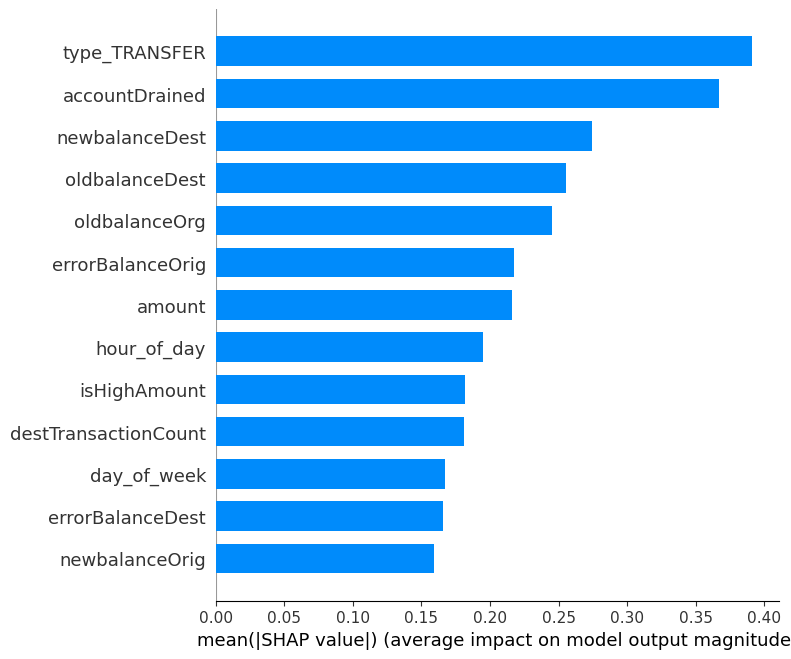

In [28]:
explainer = shap.TreeExplainer(best_model_if_tuned)
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")

# 8. Models Comparison

## 8.1 Results Summary

| Model | Precision | Recall | F1-Score | PR-AUC |
| :--- | :--- | :--- | :--- | :--- |
|LR Default|0.9188|0.5782|0.7097|0.7779|
|LR Tuned|0.1001|0.9726|0.1814|0.7844|
|LightGBM Default|0.6032|0.5819|0.5923|0.3623|
|LightGBM Tuned|0.9988|0.9927|0.9957|0.9965|
|Iso Default|0.0154|0.6488|0.0301|0.0340|
|Iso Tuned|0.0016|0.0006|0.0009|0.0206|

## 8.2 PR-AUC Curve

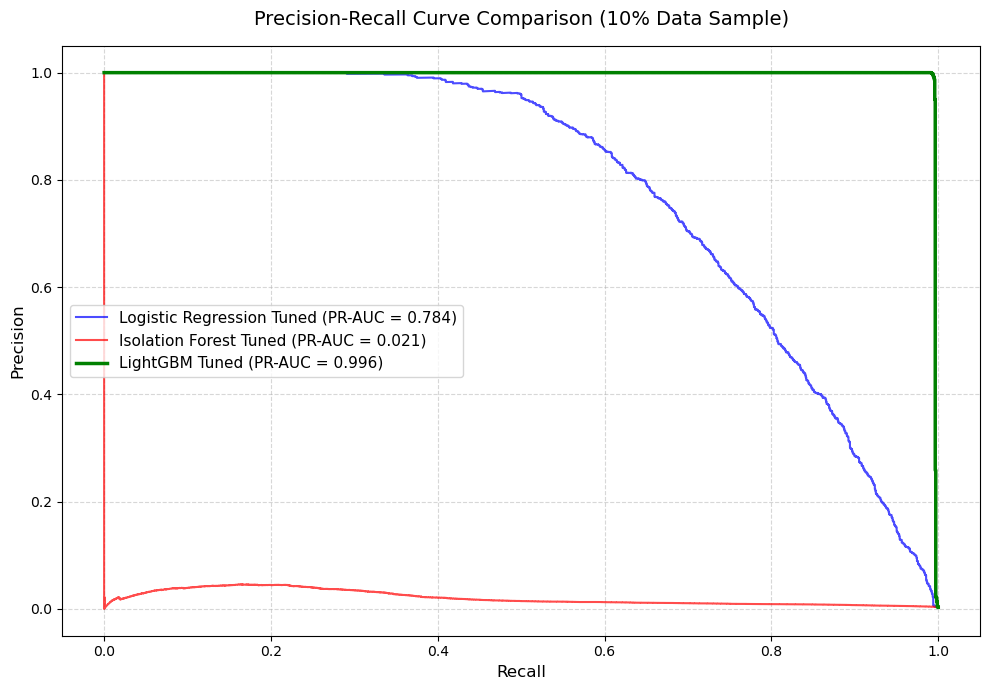

In [59]:
plt.figure(figsize=(10, 7))

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_scores_log_tuned)
plt.plot(recall_lr, precision_lr, label='Logistic Regression Tuned (PR-AUC = 0.784)', color='blue', alpha=0.7)

precision_if, recall_if, _ = precision_recall_curve(y_test, y_score_if_tuned)
plt.plot(recall_if, precision_if, label='Isolation Forest Tuned (PR-AUC = 0.021)', color='red', alpha=0.7)

precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_scores_lgbm_tuned)
plt.plot(recall_lgbm, precision_lgbm, label='LightGBM Tuned (PR-AUC = 0.996)', color='green', linewidth=2.5)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve Comparison (10% Data Sample)', fontsize=14, pad=15)
plt.legend(loc='center left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## 8.2 Final Decision

Based on the comprehensive evaluation on the 10% data sample, the Tuned LightGBM is the undisputed winner and will be selected for final training on the full 100% dataset.  

**Why LightGBM:**  
* **Unmatched Performance:** It achieved the highest scores across all critical metrics: **Recall (99.27%), Precision (99.88%), and F1-Score (99.57%), PR-AUC (99.65 %)**.
* **Perfect PR-AUC Curve:** As seen on the Precision-Recall plot above, the LightGBM curve is nearly perfect, almost entirely hugging the top-right corner. This visually proves its exceptional ability to separate the extreme minority Fraud class (0.13%) from genuine transactions without the typical drop in Precision.


# 9. Final Model Training (100% Data)

In [45]:
param_final = {
    'n_estimators':      [500, 1000, 2000],
    'max_depth':         [8, 10, 12, -1],
    'learning_rate':     loguniform(0.01, 0.1),
    'num_leaves':        randint(64,255),
    'min_child_samples': randint(20,100),
    'subsample':         uniform(0.7, 0.3),
    'colsample_bytree':  uniform(0.7, 0.3),
    'class_weight':      ['balanced', None]
}
search_final = RandomizedSearchCV(
                        estimator=LGBMClassifier(
                         random_state=42,
                         n_jobs = -1,
                         verbose=-1),
    param_distributions=param_final,
    n_iter=15,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search_final.fit(X_train, y_train)
print('The best parameters:', search_final.best_params_)
best_model_final = search_final.best_estimator_
y_pred_final = best_model_final.predict(X_test)
y_scores_final = search_final.best_estimator_.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 15 candidates, totalling 75 fits
The best parameters: {'class_weight': 'balanced', 'colsample_bytree': np.float64(0.7888820517112247), 'learning_rate': np.float64(0.0146307617777917), 'max_depth': 8, 'min_child_samples': 90, 'n_estimators': 500, 'num_leaves': 151, 'subsample': np.float64(0.8184644554526709)}


## 9.1 Model Results

  LGBMClassifier - Final
--------------
Precision: 0.9927
Recall:    0.9970
F1:        0.9948
PR-AUC:    0.9981


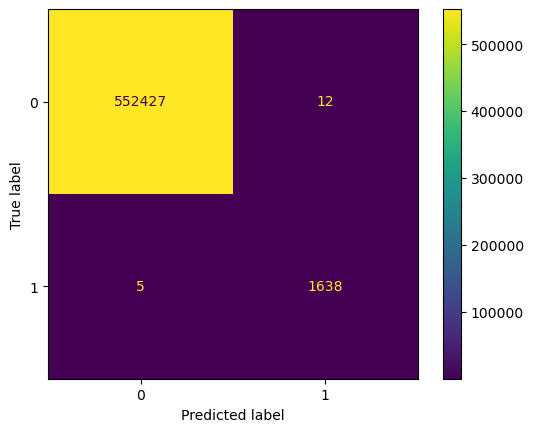

In [48]:
results("LGBMClassifier - Final", y_test, y_pred_final, y_scores_final)

## 9.2 Feature Importance

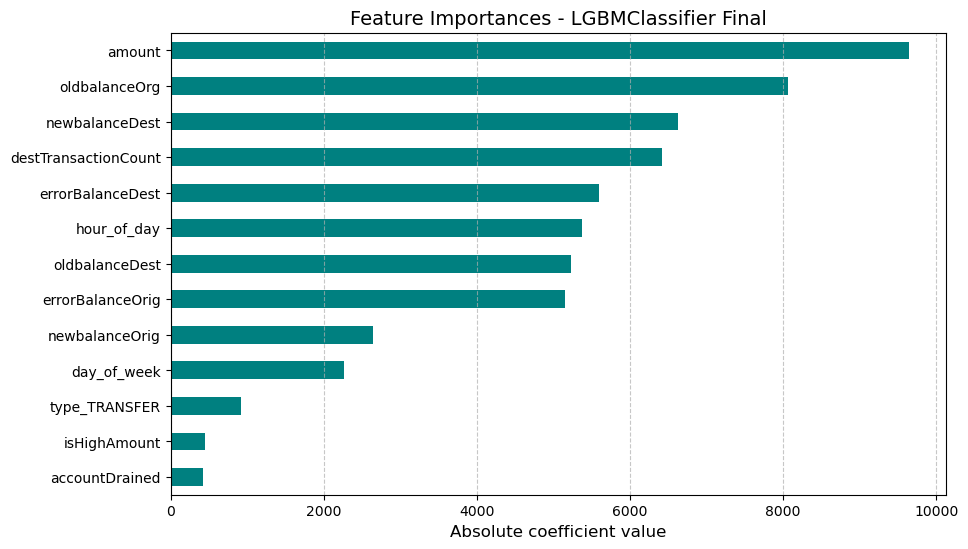

In [53]:
feature_importance(best_model_final, X_train.columns, "LGBMClassifier Final")

# 9.3 PR-AUC Curve

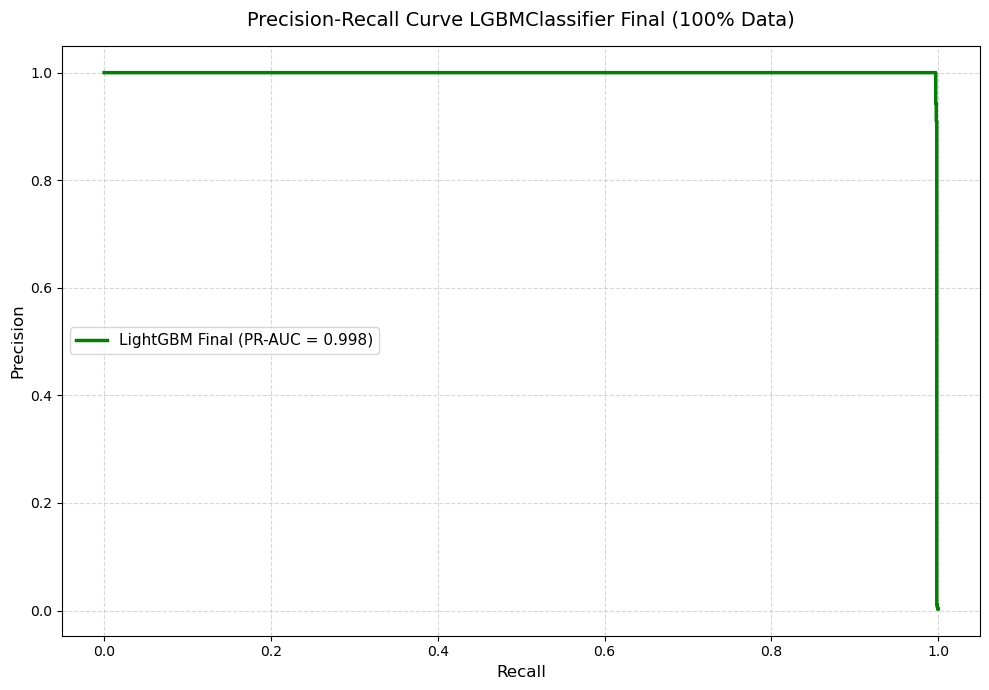

In [56]:
plt.figure(figsize=(10, 7))
precision_final, recall_final, _ = precision_recall_curve(y_test, y_scores_final)
plt.plot(recall_final, precision_final, label='LightGBM Final (PR-AUC = 0.998)', color='green', linewidth=2.5)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve LGBMClassifier Final (100% Data)', fontsize=14, pad=15)
plt.legend(loc='center left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


## 9.4 Save Model

In [57]:
import joblib

In [58]:
joblib.dump(best_model_final, 'Fraud-LGBMClassifier.pkl')

['Fraud-LGBMClassifier.pkl']

## 9.5 Final Conclusion